In [1]:
import numpy as np
import matplotlib.pyplot as plt
import limpy.lline as ll
#from plotsettings import *
import limpy.theory as lt
import limpy.utils as lu
from limpy.plotsettings import *

pl.rcParams['lines.dashed_pattern']= 5.7, 1.6

pl.rcParams['lines.dotted_pattern']= 1.5, 1.6

import matplotlib.colors as colors

In [2]:
boxsize=80
halo_redshift=5.8
nu_obs=280
dnu=2.8
line_name='CII'
ndim_original=3

mmin=1e11
ngrid=512
nproj=1


halo_file='/Users/anirbanroy/Documents/21cmFAST/Output_files/Halo_lists/halos_z5.80_512_80Mpc'

proj_L=lu.length_projection(nu_obs=nu_obs, dnu=dnu, line_name=line_name)

hm, cm=lu.make_halocat(halo_file, filetype='dat',boxsize=boxsize)

mass_cut=hm >= mmin
halomass_cut=hm[mass_cut]

print("Calculating line luminosities")
lum_line=np.zeros(len(halomass_cut))
for i in range(len(halomass_cut)):
    lum_line[i]=ll.mhalo_to_lline(halomass_cut[i],halo_redshift,line_name=line_name)

print("making the luminsoity grid")
gi=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift, line_name='CII',\
                        halo_cutoff_mass=mmin, use_scatter=False,halocat_file_type='dat', intensity_unit='jy/sr')

print("shape of gi is", np.shape(gi))

Calculating line luminosities
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
shape of gi is (134217728,)


In [3]:
boxsize=80
halo_redshift=5.8
nu_obs=280
dnu=2.8
line_name='CII'
ndim_original=3

mmin=1e11
ngrid=512
nproj=1


halo_file='/Users/anirbanroy/Documents/21cmFAST/Output_files/Halo_lists/halos_z5.80_512_80Mpc'

proj_L=lu.length_projection(nu_obs=nu_obs, dnu=dnu, line_name=line_name)

hm, cm=lu.make_halocat(halo_file, filetype='dat',boxsize=boxsize)

mass_cut=hm >= mmin
halomass_cut=hm[mass_cut]

print("Calculating line luminosities")
lum_line=np.zeros(len(halomass_cut))
for i in range(len(halomass_cut)):
    lum_line[i]=ll.mhalo_to_lline(halomass_cut[i],halo_redshift,line_name=line_name)

print("making the luminsoity grid")
gi=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift, line_name='CII',\
                        halo_cutoff_mass=mmin, use_scatter=False,halocat_file_type='dat', intensity_unit='jy/sr')

print("shape of gi is", np.shape(gi))

Calculating line luminosities
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
shape of gi is (134217728,)


In [4]:
g3d=gi.reshape(512,512,512)

k80, pk80= lu.powerspectra_2d(g3d, boxsize, ngrid, project_length=proj_L, volume_normalization=False)

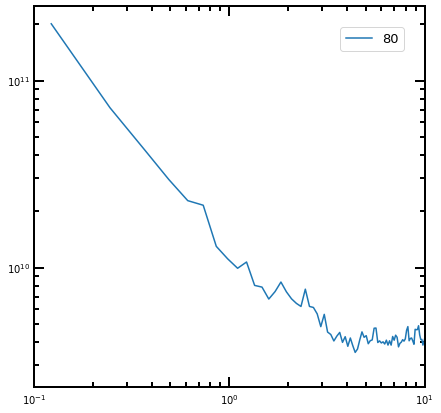

In [7]:
plt.loglog(k80, pk80, label="80")
#plt.loglog(k_ns, k_ns**3*pk_ns/2.0/np.pi**2, label="500")
plt.xlim(1e-1, 1e1)
plt.legend(loc=0)

In [6]:
print("making the luminsoity grid")
gi=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift, line_name='CII',\
                        halo_cutoff_mass=mmin, use_scatter=False,halocat_file_type='dat', intensity_unit='jy/sr')

k_s, pk_s= lu.powerspectra_2d(gi, boxsize, ngrid, project_length=proj_L, volume_normalization=False)

dk_s_sims=((k_s)**3*(pk_s))/(2*np.pi**2)

making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0


In [7]:
pk_theory=lt.Pk_line(k_s,5.8,line_name=line_name,label='total',pk_unit='intensity')
dk_theory=k_s**3*pk_theory/(2*np.pi**2)

In [8]:
kkul, dkkul=np.loadtxt("/Users/anirbanroy/Downloads/CII_kulkarni_z6.3.dat", unpack=True)

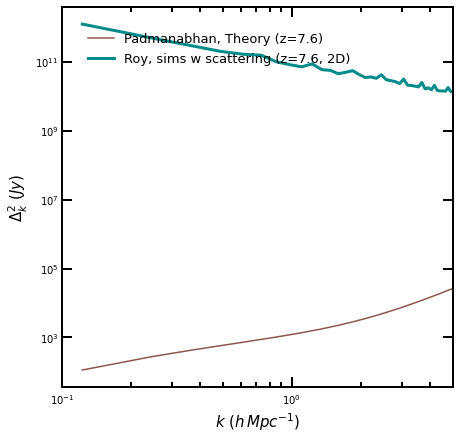

In [33]:
#d_3i=(k_3i[1:])**3 * p_3i/2.0/np.pi**2

#plt.plot(kkul, dkkul,lw=1.5, color='m',label="Kulkarni, sims (z=6.3)")
plt.plot(k_s, dk_theory,lw=1.5,color='C5', label="Padmanabhan, Theory (z=7.6)")

#plt.plot(k_s, dk_s_sims/(4*np.pi)**2,lw=4,color='r', label="Roy, w/o scattering (z=5.8, 2D)")
plt.plot(k_s, dk_s_sims,lw=3,color='darkcyan', label="Roy, sims w scattering (z=7.6, 2D)")
#plt.plot(k_3i[1:], d_3i/(4*np.pi)**2, lw=4, color='tomato', label="Roy, w/o scattering (z=5.8, 3D)")

plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-1, 5)
#plt.ylim(1e2, 1e10)
plt.legend(loc=2, frameon=False, fontsize=13)

#plt.xlim((2*np.pi)/80, (np.pi*512)/80)

plt.ylabel(r"$\Delta_k^2\,\,(Jy)$")
plt.xlabel(r"$k\,\,(h\,Mpc^{-1})$")

plt.savefig("powerspecta.pdf")

In [10]:
k=[]
pk=[]
for i in range(20):
    print("doing for loop no", i)
    
    #print("making the luminsoity grid")
    gi=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift, line_name='CII',\
                        halo_cutoff_mass=mmin, use_scatter=True,halocat_file_type='dat', intensity_unit='jy/sr')

    #print("shape of gi is", np.shape(gi))
    
    g3d=gi.reshape(512,512,512)
    #print("Calculating power spectra")
    k_ns, pk_ns= lu.powerspectra_2d(g3d, boxsize, ngrid, project_length=proj_L, volume_normalization=False)
    k.append(k_ns), pk.append(pk_ns)

doing for loop no 0
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 1
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 2
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 3
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 4
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 5
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 6
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 7
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 8
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 9
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 10
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
doing for loop no 11
Minimum halo mass: 336666900.0
M

No handles with labels found to put in legend.


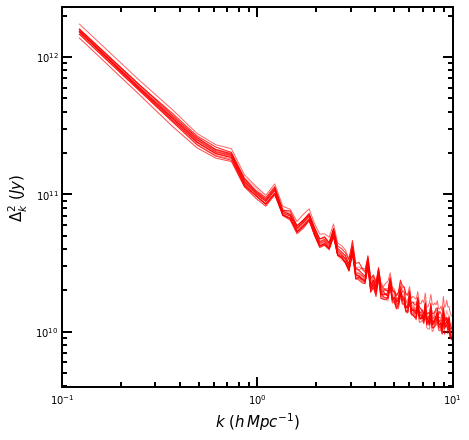

In [32]:
#d_3i=(k_3i[1:])**3 * p_3i/2.0/np.pi**2

#plt.plot(kkul, dkkul,lw=1.5, color='m',label="Kulkarni, sims (z=6.3)")
#plt.plot(k_s, dk_theory,lw=1.5,color='C5', label="Padmanabhan, Theory (z=7.6)")


for j in range(len(k)):
    #dk=k[j]**3*pk[j]/2.0/np.pi**2
    dk=pk[j]
    plt.plot(k[j], dk, lw=1, color='r', alpha=0.05*j)


#plt.plot(k_s, dk_s_sims/(4*np.pi)**2,lw=4,color='r', label="Roy, w/o scattering (z=5.8, 2D)")
#plt.plot(k_s, dk_s_sims,lw=3,color='darkcyan', label="Roy, sims w scattering (z=7.6, 2D)")
#plt.plot(k_3i[1:], d_3i/(4*np.pi)**2, lw=4, color='tomato', label="Roy, w/o scattering (z=5.8, 3D)")

plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-1, 10)
#plt.ylim(1e2, 1e10)
plt.legend(loc=2, frameon=False, fontsize=13)

#plt.xlim((2*np.pi)/80, (np.pi*512)/80)

plt.ylabel(r"$\Delta_k^2\,\,(Jy)$")
plt.xlabel(r"$k\,\,(h\,Mpc^{-1})$")

plt.savefig("powerspecta.pdf")

# calculate and plot CII 2D power spectra for different redshifts 

In [21]:
boxsize=80
halo_redshift=[3.60, 4.40, 5.80, 7.60]
nu_obs=[410, 350, 280, 220]
dnu=[4.1, 3.5, 2.8, 2.2]
line_name='CII'
ndim_original=3

mmin=1e10
ngrid=512
kz_c2=[]
pkz_c2=[]

for i in range(len(halo_redshift)):
    print("Calculating line luminosities for redsift=", halo_redshift[i])
    halo_file='/Users/anirbanroy/Documents/21cmFAST/Output_files/Halo_lists/halos_z%1.2f_512_80Mpc' %(halo_redshift[i])

    proj_L=utils.length_projection(nu_obs=nu_obs[i], dnu=dnu[i], line_name=line_name)
    
    print("Reading halo catalougue")
    hm, cm=utils.make_halocat(halo_file, filetype='dat',boxsize=boxsize)

    mass_cut=hm >= mmin
    halomass_cut=hm[mass_cut]
    lum_line=np.zeros(len(halomass_cut))
    #for i in range(len(halomass_cut)):
    #    lum_line[i]=ll.mhalo_to_lline(halomass_cut[i],halo_redshift,line_name=line_name)

    print("making the luminsoity grid")
    gi=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift[i], line_name='CII',\
                        halo_cutoff_mass=1e10, use_scatter=False,halocat_file_type='dat')
    
    gi=gi.reshape(512,512,512)
    
    kz_ns_c2, pkz_ns_c2= utils.powerspectra_2d(gi, boxsize, ngrid, project_length= proj_L, volume_normalization=False)
    
    kz_c2.append(kz_ns_c2), pkz_c2.append(pkz_ns_c2)

Calculating line luminosities for redsift= 3.6
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 7471935000000.0
Calculating line luminosities for redsift= 4.4
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 4217712000000.0
Calculating line luminosities for redsift= 5.8
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
Calculating line luminosities for redsift= 7.6
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 321717300000.0


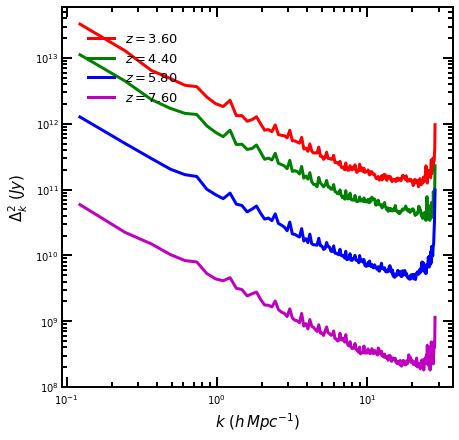

In [31]:
colorlist=['r', 'g', 'b', 'm']
label_list=[r'$z=3.60$', r'$z=4.40$', r'$z=5.80$', r'$z=7.60$' ]
for i in range(len(halo_redshift)):
    kplot=kz_c2[i]
    pkplot=pkz_c2[i]
    #dkplot=kplot**3*pkplot/2.0/np.pi**2
    dkplot=pkplot
    plt.plot(kplot, dkplot, lw=3, color=colorlist[i], label=label_list[i])
    
plt.legend(loc=0)

plt.xscale("log")
plt.yscale("log")
#plt.xlim(1e-1, 5)
#plt.ylim(1e4, 5e10)
plt.legend(loc=2, frameon=False, fontsize=13)

#plt.xlim((2*np.pi)/80, (np.pi*512)/80)

plt.ylabel(r"$\Delta_k^2\,\,(Jy)$")
plt.xlabel(r"$k\,\,(h\,Mpc^{-1})$")

plt.savefig("ps_CII_redshift.pdf")

In [24]:
kz_o=[]
pkz_o=[]

line_name='OIII'
for i in range(len(halo_redshift)):
    print("Calculating line luminosities for redsift=", halo_redshift[i])
    halo_file='/Users/anirbanroy/Documents/21cmFAST/Output_files/Halo_lists/halos_z%1.2f_512_80Mpc' %(halo_redshift[i])

    proj_L=utils.length_projection(nu_obs=nu_obs[i], dnu=dnu[i], line_name=line_name)
    
    print("Reading halo catalougue")
    hm, cm=utils.make_halocat(halo_file, filetype='dat',boxsize=boxsize)

    mass_cut=hm >= mmin
    halomass_cut=hm[mass_cut]
    lum_line=np.zeros(len(halomass_cut))
    #for i in range(len(halomass_cut)):
    #    lum_line[i]=ll.mhalo_to_lline(halomass_cut[i],halo_redshift,line_name=line_name)

    print("making the luminsoity grid")
    gi=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift[i], line_name='CII',\
                        halo_cutoff_mass=1e10, use_scatter=False,halocat_file_type='dat')
    
    gi=gi.reshape(512,512,512)
    
    kz_ns_o, pkz_ns_o= utils.powerspectra_2d(gi, boxsize, ngrid, project_length= proj_L, volume_normalization=False)
    
    kz_o.append(kz_ns_o), pkz_o.append(pkz_ns_o)

Calculating line luminosities for redsift= 3.6
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 7471935000000.0
Calculating line luminosities for redsift= 4.4
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 4217712000000.0
Calculating line luminosities for redsift= 5.8
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
Calculating line luminosities for redsift= 7.6
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 321717300000.0


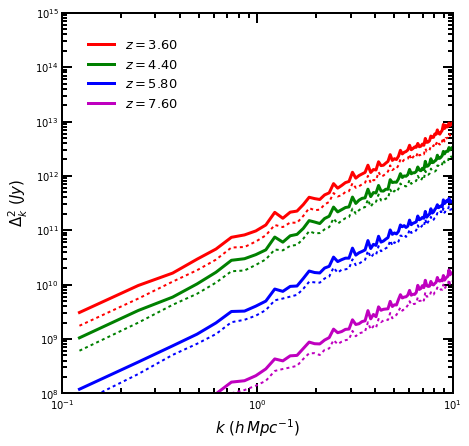

In [27]:
colorlist=['r', 'g', 'b', 'm']
label_list=[r'$z=3.60$', r'$z=4.40$', r'$z=5.80$', r'$z=7.60$' ]
for i in range(len(halo_redshift)):
    kplot_c2=kz_c2[i]
    pkplot_c2=pkz_c2[i]
    dkplot_c2=kplot_c2**3*pkplot_c2/2.0/np.pi**2
    
    
    kplot_o=kz_o[i]
    pkplot_o=pkz_o[i]
    dkplot_o=kplot_o**3*pkplot_o/2.0/np.pi**2
    
    
    
    plt.plot(kplot_c2, dkplot_c2, lw=3, color=colorlist[i], label=label_list[i])
    
    plt.plot(kplot_o, dkplot_o, lw=2, ls=':', color=colorlist[i])
    
plt.legend(loc=0)

plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-1, 10)
plt.ylim(1e8, 1e15)
plt.legend(loc=2, frameon=False, fontsize=13)

#plt.xlim((2*np.pi)/80, (np.pi*512)/80)

plt.ylabel(r"$\Delta_k^2\,\,(Jy)$")
plt.xlabel(r"$k\,\,(h\,Mpc^{-1})$")

plt.savefig("ps_CII_redshift.pdf")

# Now, let's calculate all cross-power spectra of CII and OIII

In [29]:
kz_xc=[]
pkz_xc=[]


for i in range(len(halo_redshift)):
    print("Calculating line luminosities for redsift=", halo_redshift[i])
    halo_file='/Users/anirbanroy/Documents/21cmFAST/Output_files/Halo_lists/halos_z%1.2f_512_80Mpc' %(halo_redshift[i])

    proj_L=utils.length_projection(nu_obs=nu_obs[i], dnu=dnu[i], line_name=line_name)
    
    print("Reading halo catalougue")
    hm, cm=utils.make_halocat(halo_file, filetype='dat',boxsize=boxsize)

    mass_cut=hm >= mmin
    halomass_cut=hm[mass_cut]
    lum_line=np.zeros(len(halomass_cut))
    #for i in range(len(halomass_cut)):
    #    lum_line[i]=ll.mhalo_to_lline(halomass_cut[i],halo_redshift,line_name=line_name)

    print("making the luminsoity grid")
    gi_CII=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift[i], line_name='CII',\
                        halo_cutoff_mass=1e10, use_scatter=False,halocat_file_type='dat')
    
    gi_OIII=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift[i], line_name='OIII',\
                        halo_cutoff_mass=1e10, use_scatter=False,halocat_file_type='dat')
    
    
    gi_c2=gi_CII.reshape(512,512,512)
    gi_o3=gi_OIII.reshape(512,512,512)
    
    #xc stands for cross-correlation
    kz_ns_xc, pkz_ns_xc= utils.powerspectra_2d(gi_c2, boxsize, ngrid, y_grid=gi_o3, project_length= proj_L, volume_normalization=False)
    
    kz_xc.append(kz_ns_xc), pkz_xc.append(pkz_ns_xc)

Calculating line luminosities for redsift= 3.6
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 7471935000000.0
Minimum halo mass: 336666900.0
Maximum halo mass: 7471935000000.0
Calculating line luminosities for redsift= 4.4
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 4217712000000.0
Minimum halo mass: 336666900.0
Maximum halo mass: 4217712000000.0
Calculating line luminosities for redsift= 5.8
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
Calculating line luminosities for redsift= 7.6
Reading halo catalougue
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 321717300000.0
Minimum halo mass: 336666900.0
Maximum halo mass: 321717300000.0


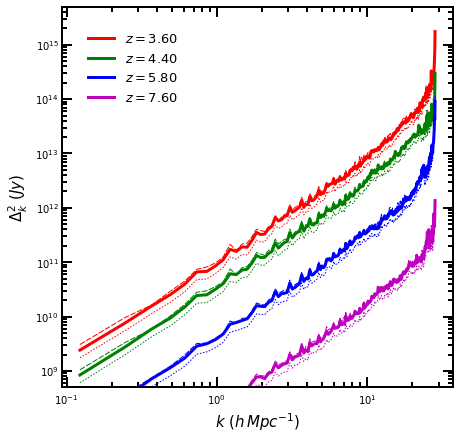

In [30]:
colorlist=['r', 'g', 'b', 'm']
label_list=[r'$z=3.60$', r'$z=4.40$', r'$z=5.80$', r'$z=7.60$' ]
for i in range(len(halo_redshift)):
    if(i>=6):
        pass
    else:
        kplot_c2=kz_c2[i]
        pkplot_c2=pkz_c2[i]
        dkplot_c2=kplot_c2**3*pkplot_c2/2.0/np.pi**2

        kplot_o=kz_o[i]
        pkplot_o=pkz_o[i]
        dkplot_o=kplot**3*pkplot_o/2.0/np.pi**2

        kplot_xc=kz_xc[i]
        pkplot_xc=pkz_xc[i]
        dkplot_xc=kplot_xc**3*pkplot_xc/2.0/np.pi**2


        plt.plot(kplot_xc, dkplot_xc, lw=3, color=colorlist[i], label=label_list[i])

        plt.plot(kplot_c2, dkplot_c2, lw=1, ls='--', color=colorlist[i])

        plt.plot(kplot_o, dkplot_o, lw=1, ls=':', color=colorlist[i])

        plt.legend(loc=0)

plt.xscale("log")
plt.yscale("log")
#plt.xlim(1e-1, 10)
plt.ylim(5e8, 5e15)
plt.legend(loc=2, frameon=False, fontsize=13)

#plt.xlim((2*np.pi)/80, (np.pi*512)/80)

plt.ylabel(r"$\Delta_k^2\,\,(Jy)$")
plt.xlabel(r"$k\,\,(h\,Mpc^{-1})$")

plt.savefig("ps_CII_xc.pdf")

# Make intensity maps from simulations. 

In [ ]:
gi_CII
gi_OII

In [ ]:
gc2=[]
go3=[]

for i in range(len(halo_redshift)):
    print("Calculating line luminosities for redsift=", halo_redshift[i])
    halo_file='/Users/anirbanroy/Documents/21cmFAST/Output_files/Halo_lists/halos_z%1.2f_512_80Mpc' %(halo_redshift[i])

    proj_L=utils.length_projection(nu_obs=nu_obs[i], dnu=dnu[i], line_name=line_name)
    
    print("Reading halo catalougue")
    hm, cm=utils.make_halocat(halo_file, filetype='dat',boxsize=boxsize)

    mass_cut=hm >= mmin
    halomass_cut=hm[mass_cut]
    lum_line=np.zeros(len(halomass_cut))
    #for i in range(len(halomass_cut)):
    #    lum_line[i]=ll.mhalo_to_lline(halomass_cut[i],halo_redshift,line_name=line_name)

    print("making the luminsoity grid")
    gi_CII=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift[i], line_name='CII',\
                        halo_cutoff_mass=1e10, use_scatter=False,halocat_file_type='dat')
    
    #gi_OIII=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift[i], line_name='OIII',\
    #                    halo_cutoff_mass=1e10, use_scatter=False,halocat_file_type='dat', unit='mpc')
    
    
    #gi_CII=gi_CII.reshape(512,512,512)
    #gi_OIII=gi_OIII.reshape(512,512,512)
    
    gc2.append(gi_CII) #, go3.append(gi_OIII) 
    

In [ ]:
m=3
go3_1=gc2[m]

i, j, val= utils.slice(go3_1, ngrid, 10)

fig = plt.figure(figsize=(7, 7), dpi=100)
ax = fig.add_subplot(1, 1, 1)


s = plt.scatter(i, j, marker='o', c=val, s=70,cmap='afmhot',  vmin=1e2, vmax=1e10, norm=colors.LogNorm(), alpha=0.9)

divider = make_axes_locatable(ax)
       
cax = divider.append_axes("right", "3%", pad="13%")
cb = plt.colorbar(s,cax=cax,orientation='vertical')
cb.set_label(r'$I_{\rm line}$',
             labelpad=5)

cb.solids.set_edgecolor("face")
ax.set_aspect('equal', 'box')

ax.set_title(label_list[m])
plt.tight_layout()
plt.savefig("map_c2_z_%s.jpg" %label_list[m])

In [ ]:
import Pk_library as PKL

df="/Users/anirbanroy/Documents/21cmFAST/Boxes/updated_smoothed_deltax_z004.40_512_80Mpc"

with open(df, 'rb') as f:
    dens_gas = np.fromfile(f, dtype='f', count=-1)
    
dens_gas=dens_gas.reshape(512,512,512)

# compute power spectrum
Pk = PKL.Pk(dens_gas, boxsize,axis=0, MAS='CIC', threads=10)

# 3D P(k)
k       = Pk.k3D
Pk0     = Pk.Pk[:,0] #monopole
Pk2     = Pk.Pk[:,1] #quadrupole
Pk4     = Pk.Pk[:,2] #hexadecapole
Pkphase = Pk.Pkphase #power spectrum of the phases
Nmodes  = Pk.Nmodes3D

In [ ]:
import powerbox as pb
pkbins, kbins=pb.get_power(dens_gas, 80, bin_ave=False, vol_normalised_power=True)

In [ ]:
plt.plot(k, k**3*Pk0/2.0/np.pi**2, lw=4.0, label="Pylian")
plt.plot(kbins[1:], kbins[1:]**3*pkbins/2.0/np.pi**2, lw=4.0, label="My code")


plt.xscale("log")
plt.yscale("log")

plt.ylabel(r"$\Delta_{\delta\delta}^2$")
plt.xlabel(r"$k\,\,(h\,Mpc^{-1})$")

plt.legend(loc=0, frameon=False, fontsize=15)
plt.ylim(1e-2,1e1)
#plt.xlim((2*np.pi/80), (np.pi*512)/80)

plt.savefig("ps_density_comparison.pdf")

In [ ]:
dens_2d=utils.slice_2d(dens_gas, ngrid, 1)
pkbins2, kbins2=pb.get_power(dens_2d, 80, bin_ave=False, vol_normalised_power=True)

In [ ]:
plt.plot(k, k**3*Pk0/2.0/np.pi**2, lw=4.0, label="Pylian, 3d")
plt.plot(kbins[1:], kbins[1:]**3*pkbins/2.0/np.pi**2, lw=4.0, label="My code, 3D")
plt.plot(kbins2[1:], kbins2[1:]**3*pkbins2/2.0/np.pi**2, lw=4, label="my code, 2D")

plt.xscale("log")
plt.yscale("log")

plt.ylabel(r"$\Delta_{\delta\delta}^2$")
plt.xlabel(r"$k\,\,(h\,Mpc^{-1})$")

plt.legend(loc=0, frameon=False, fontsize=15)
plt.ylim(1e-4,1e1)
plt.xlim((2*np.pi/80), (np.pi*512)/80)
plt.savefig("ps_compariosn.pdf")

In [ ]:
i=0
proj_L=utils.length_projection(nu_obs=nu_obs[i], dnu=dnu[i], line_name=line_name)
proj_L